<a href="https://colab.research.google.com/github/ahad77/Assignment/blob/main/Titanic_EDA_Ahad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

***Set aesthetics for professional reporting***

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

***Data Ingestion & Initial Inspection***

In [ ]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv"
df = pd.read_csv(url)

In [ ]:
print("--- Initial Data Profiling ---")
print(df.head())
print(df.info())
print("\n--- Descriptive Statistics ---")
print(df.describe())
print("\n--- Missing Value Analysis ---")
print(df.isnull().sum())

--- Initial Data Profiling ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            3734

***Univariate Analysis***

Survival Rate Distribution

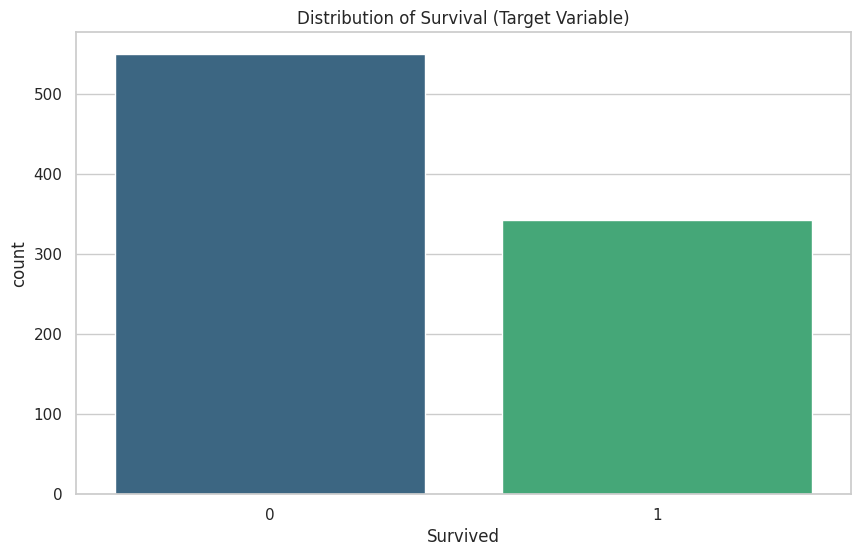

Overall Survival Rate: 38.38%


In [ ]:
plt.figure()
sns.countplot(data=df, x='Survived', palette='viridis', hue='Survived', legend=False)
plt.title('Distribution of Survival (Target Variable)')
plt.show()

survival_rate = df['Survived'].mean() * 100
print(f"Overall Survival Rate: {survival_rate:.2f}%")

Pclass Distribution

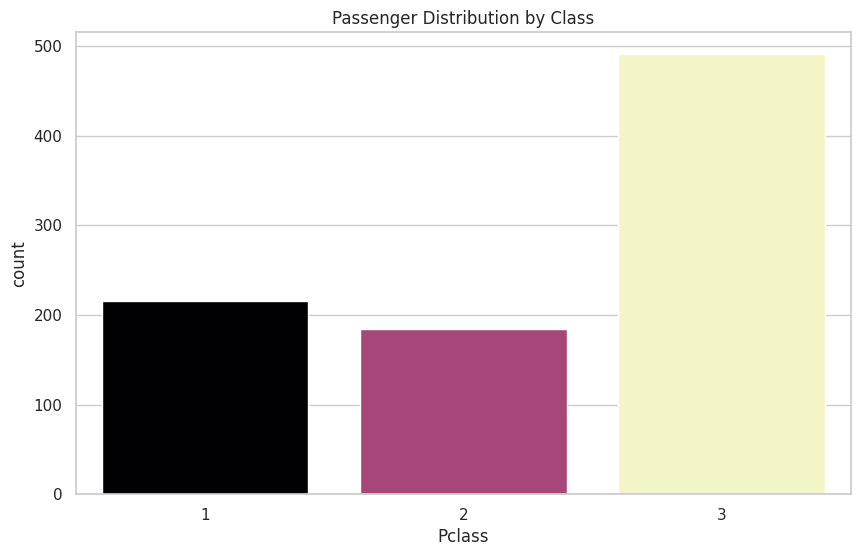

In [ ]:
plt.figure()
sns.countplot(data=df, x='Pclass', palette='magma', hue='Pclass', legend=False)
plt.title('Passenger Distribution by Class')
plt.show()

***Bivariate & Multivariate Analysis***

Survival by Sex (Strongest Predictor)

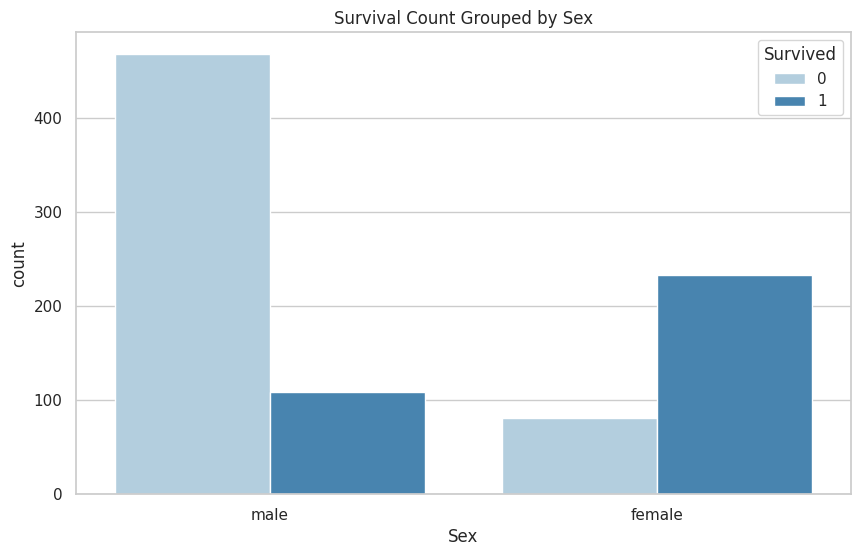

In [ ]:
plt.figure()
sns.countplot(data=df, x='Sex', hue='Survived', palette='Blues')
plt.title('Survival Count Grouped by Sex')
plt.show()

Survival by Pclass (Socio-Economic Signal)

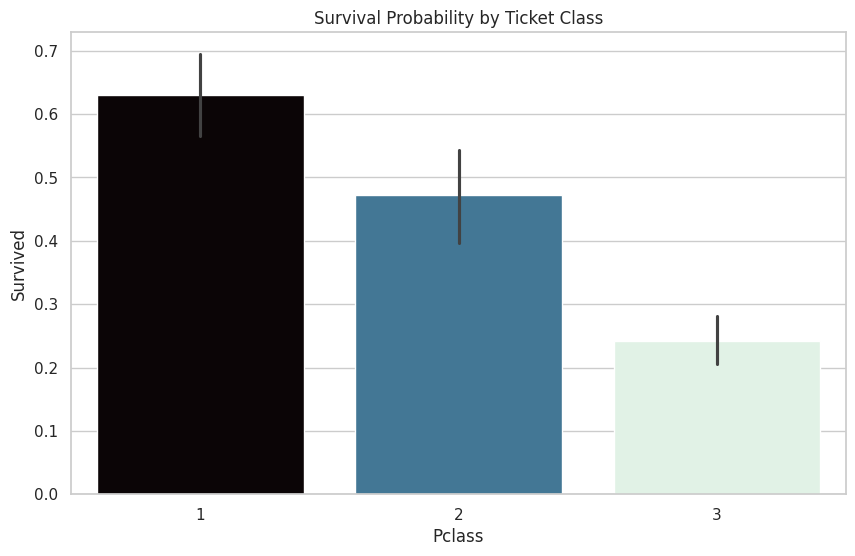

In [ ]:
plt.figure()
sns.barplot(data=df, x='Pclass', y='Survived', palette='mako', hue='Pclass', legend=False)
plt.title('Survival Probability by Ticket Class')
plt.show()

Survival by Age (Non-Linear Relationship)

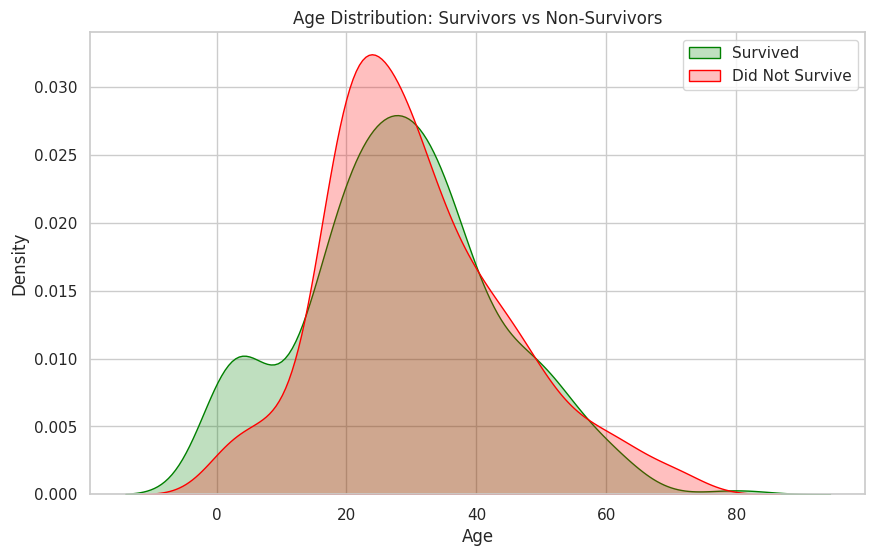

In [ ]:
plt.figure()
sns.kdeplot(data=df[df['Survived'] == 1]['Age'], label='Survived', fill=True, color='green')
sns.kdeplot(data=df[df['Survived'] == 0]['Age'], label='Did Not Survive', fill=True, color='red')
plt.title('Age Distribution: Survivors vs Non-Survivors')
plt.xlabel('Age')
plt.legend()
plt.show()

Survival by Port of Embarkation

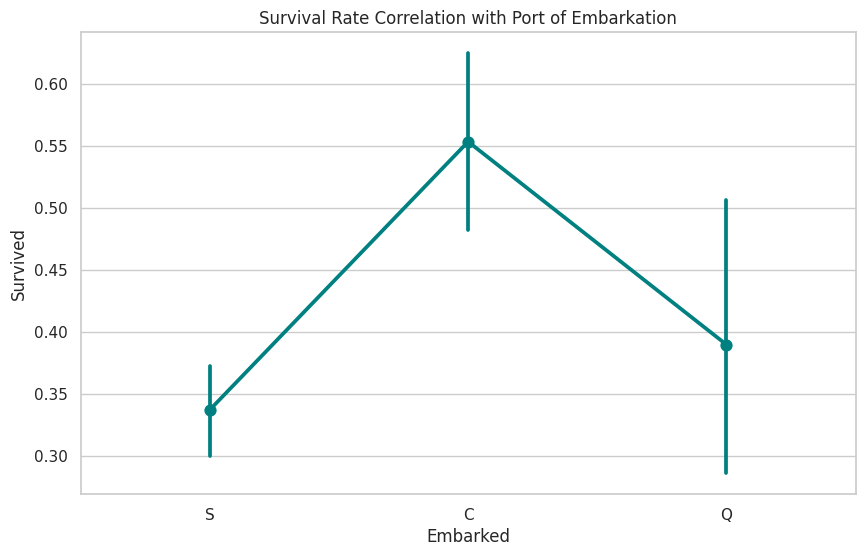

In [ ]:
plt.figure()
sns.pointplot(data=df, x='Embarked', y='Survived', color='teal')
plt.title('Survival Rate Correlation with Port of Embarkation')
plt.show()

***Engineering Synthesis***

In [ ]:
def generate_insights():
    summary = """
    ENGINEERING SUMMARY:
    1. Feature Dominance: 'Sex' and 'Pclass' exhibit the highest mutual information with the target.
    2. Demographic Bias: The 'Women and Children First' protocol is statistically visible,
       with a massive survival delta between genders and a survival spike in the [0-10] age cohort.
    3. Economic Proxy: 'Pclass' acts as a high-fidelity proxy for lifeboat access; 1st class passengers
       had a survival probability >60%, while 3rd class was <25%.
    """
    print(summary)

generate_insights()


    ENGINEERING SUMMARY:
    1. Feature Dominance: 'Sex' and 'Pclass' exhibit the highest mutual information with the target.
    2. Demographic Bias: The 'Women and Children First' protocol is statistically visible,
       with a massive survival delta between genders and a survival spike in the [0-10] age cohort.
    3. Economic Proxy: 'Pclass' acts as a high-fidelity proxy for lifeboat access; 1st class passengers
       had a survival probability >60%, while 3rd class was <25%.
    
